In [1]:
# 1) Mount Drive (if not yet)
# -------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import shutil
import datetime
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import itertools
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [3]:
# PATH SETUP
# =========================
DRIVE_ROOT = "/content/drive/MyDrive/Colab Notebooks"
SPLIT70_DIR = f"{DRIVE_ROOT}/emotion/emotion_preprocessed_split80_20_aug4000"  # train/val

TEST_DIR = f"{DRIVE_ROOT}/emotion/emotion_preprocessed/test"

LOCAL_TRAIN = "/content/data/train"
LOCAL_VAL   = "/content/data/val"
LOCAL_TEST  = "/content/data/test"

ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = f"{DRIVE_ROOT}/Emotion_VGG16_70_30_Improved_Results_o{ts}"
os.makedirs(OUT_DIR, exist_ok=True)

def fresh_copy(src, dst):
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

print("Copying train/val/test to Colab local...")
fresh_copy(os.path.join(SPLIT70_DIR, "train"), LOCAL_TRAIN)
fresh_copy(os.path.join(SPLIT70_DIR, "val"),   LOCAL_VAL)
fresh_copy(TEST_DIR, LOCAL_TEST)
print("✅ Copy complete.")


Copying train/val/test to Colab local...
✅ Copy complete.


In [4]:
# =========================
# DATA GENERATORS
# =========================
BATCH_SIZE = 32
IMG_SIZE = (224,224)

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    LOCAL_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    LOCAL_VAL,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    LOCAL_TEST,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)


Found 28000 images belonging to 7 classes.
Found 5744 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [5]:
# =========================
# BUILD VGG16 MODEL
# =========================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Feature extraction first (freeze all)
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.6)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
preds = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=preds)
optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [6]:
# =========================
# CALLBACKS
# =========================
checkpoint = ModelCheckpoint(os.path.join(OUT_DIR, 'best_model.h5'), monitor='val_accuracy', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1)

# =========================
# TRAIN FEATURE EXTRACTION FIRST
# =========================
EPOCHS_FE = 10
history_fe = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//BATCH_SIZE + 1,
    validation_data=val_generator,
    validation_steps=val_generator.samples//BATCH_SIZE + 1,
    epochs=EPOCHS_FE,
    callbacks=[checkpoint, reduce_lr, early_stop]
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.3513 - loss: 2.0100

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from -inf to 0.50226, saving model to /content/drive/MyDrive/Colab Notebooks/Emotion_VGG16_70_30_Improved_Results_o20251005_141523/best_model.h5


...

876/876 ━━━━━━━━━━━━━━━━━━━━ 181s 206ms/step - accuracy: 0.5182 - loss: 1.2959 - val_accuracy: 0.5099 - val_loss: 1.2790 - learning_rate: 0.0010
Epoch 3/10
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.5617 - loss: 1.1739
Epoch 3: val_accuracy improved from 0.50992 to 0.51532, saving model to /content/drive/MyDrive/Colab Notebooks/Emotion_VGG16_70_30_Improved_Results_o20251005_141523/best_model.h5


876/876 ━━━━━━━━━━━━━━━━━━━━ 181s 207ms/step - accuracy: 0.5617 - loss: 1.1740 - val_accuracy: 0.5153 - val_loss: 1.2756 - learning_rate: 0.0010
Epoch 4/10
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.5804 - loss: 1.1291
Epoch 4: val_accuracy improved from 0.51532 to 0.53081, saving model to /content/drive/MyDrive/Colab Notebooks/Emotion_VGG16_70_30_Improved_Results_o20251005_141523/best_model.h5


876/876 ━━━━━━━━━━━━━━━━━━━━ 181s 206ms/step - accuracy: 0.5804 - loss: 1.1291 - val_accuracy: 0.5308 - val_loss: 1.2466 - learning_rate: 0.0010
Epoch 5/10
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6096 - loss: 1.0614
Epoch 5: val_accuracy did not improve from 0.53081
876/876 ━━━━━━━━━━━━━━━━━━━━ 178s 203ms/step - accuracy: 0.6096 - loss: 1.0614 - val_accuracy: 0.5287 - val_loss: 1.2642 - learning_rate: 0.0010
Epoch 6/10
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6157 - loss: 1.0195
Epoch 6: val_accuracy improved from 0.53081 to 0.53708, saving model to /content/drive/MyDrive/Colab Notebooks/Emotion_VGG16_70_30_Improved_Results_o20251005_141523/best_model.h5


876/876 ━━━━━━━━━━━━━━━━━━━━ 181s 207ms/step - accuracy: 0.6157 - loss: 1.0196 - val_accuracy: 0.5371 - val_loss: 1.2381 - learning_rate: 0.0010
Epoch 7/10
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6384 - loss: 0.9793
Epoch 7: val_accuracy did not improve from 0.53708
876/876 ━━━━━━━━━━━━━━━━━━━━ 178s 203ms/step - accuracy: 0.6384 - loss: 0.9793 - val_accuracy: 0.5355 - val_loss: 1.2458 - learning_rate: 0.0010
Epoch 8/10
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6577 - loss: 0.9221
Epoch 8: val_accuracy did not improve from 0.53708

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
876/876 ━━━━━━━━━━━━━━━━━━━━ 178s 203ms/step - accuracy: 0.6577 - loss: 0.9222 - val_accuracy: 0.5183 - val_loss: 1.3085 - learning_rate: 0.0010
Epoch 9/10
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6913 - loss: 0.8371
Epoch 9: val_accuracy improved from 0.53708 to 0.56111, saving model to /content/drive/MyDrive/Colab Notebooks/Emotion_VGG

876/876 ━━━━━━━━━━━━━━━━━━━━ 185s 211ms/step - accuracy: 0.6913 - loss: 0.8371 - val_accuracy: 0.5611 - val_loss: 1.2359 - learning_rate: 5.0000e-04
Epoch 10/10
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7149 - loss: 0.7756
Epoch 10: val_accuracy did not improve from 0.56111
876/876 ━━━━━━━━━━━━━━━━━━━━ 195s 203ms/step - accuracy: 0.7149 - loss: 0.7756 - val_accuracy: 0.5510 - val_loss: 1.2848 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 9.


In [7]:
# =========================
# UNFREEZE LAST CONV BLOCK
# =========================
for layer in base_model.layers[:-4]:
    layer.trainable = False
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Recompile with lower LR
optimizer_finetune = Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer_finetune, loss='categorical_crossentropy', metrics=['accuracy'])

In [8]:
# TRAIN FINE-TUNING
# =========================
EPOCHS_FT = 15
history_ft = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//BATCH_SIZE + 1,
    validation_data=val_generator,
    validation_steps=val_generator.samples//BATCH_SIZE + 1,
    epochs=EPOCHS_FT,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Epoch 1/15
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.7255 - loss: 0.7610
Epoch 1: val_accuracy improved from 0.56111 to 0.56877, saving model to /content/drive/MyDrive/Colab Notebooks/Emotion_VGG16_70_30_Improved_Results_o20251005_141523/best_model.h5


876/876 ━━━━━━━━━━━━━━━━━━━━ 224s 247ms/step - accuracy: 0.7255 - loss: 0.7609 - val_accuracy: 0.5688 - val_loss: 1.2174 - learning_rate: 1.0000e-05
Epoch 2/15
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.7639 - loss: 0.6582
Epoch 2: val_accuracy improved from 0.56877 to 0.57120, saving model to /content/drive/MyDrive/Colab Notebooks/Emotion_VGG16_70_30_Improved_Results_o20251005_141523/best_model.h5


876/876 ━━━━━━━━━━━━━━━━━━━━ 212s 242ms/step - accuracy: 0.7639 - loss: 0.6582 - val_accuracy: 0.5712 - val_loss: 1.2076 - learning_rate: 1.0000e-05
Epoch 3/15
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.7972 - loss: 0.5822
Epoch 3: val_accuracy improved from 0.57120 to 0.57503, saving model to /content/drive/MyDrive/Colab Notebooks/Emotion_VGG16_70_30_Improved_Results_o20251005_141523/best_model.h5


876/876 ━━━━━━━━━━━━━━━━━━━━ 215s 246ms/step - accuracy: 0.7972 - loss: 0.5822 - val_accuracy: 0.5750 - val_loss: 1.2388 - learning_rate: 1.0000e-05
Epoch 4/15
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8266 - loss: 0.5128
Epoch 4: val_accuracy did not improve from 0.57503

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
876/876 ━━━━━━━━━━━━━━━━━━━━ 208s 237ms/step - accuracy: 0.8266 - loss: 0.5128 - val_accuracy: 0.5740 - val_loss: 1.2518 - learning_rate: 1.0000e-05
Epoch 5/15
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8648 - loss: 0.4268
Epoch 5: val_accuracy improved from 0.57503 to 0.57956, saving model to /content/drive/MyDrive/Colab Notebooks/Emotion_VGG16_70_30_Improved_Results_o20251005_141523/best_model.h5


876/876 ━━━━━━━━━━━━━━━━━━━━ 217s 247ms/step - accuracy: 0.8648 - loss: 0.4268 - val_accuracy: 0.5796 - val_loss: 1.2574 - learning_rate: 5.0000e-06
Epoch 6/15
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8835 - loss: 0.3828
Epoch 6: val_accuracy did not improve from 0.57956

Epoch 6: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
876/876 ━━━━━━━━━━━━━━━━━━━━ 209s 238ms/step - accuracy: 0.8835 - loss: 0.3828 - val_accuracy: 0.5789 - val_loss: 1.2612 - learning_rate: 5.0000e-06
Epoch 7/15
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8998 - loss: 0.3453
Epoch 7: val_accuracy did not improve from 0.57956
876/876 ━━━━━━━━━━━━━━━━━━━━ 207s 237ms/step - accuracy: 0.8998 - loss: 0.3453 - val_accuracy: 0.5794 - val_loss: 1.2766 - learning_rate: 2.5000e-06
Epoch 8/15
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9063 - loss: 0.3259
Epoch 8: val_accuracy did not improve from 0.57956

Epoch 8: ReduceLROnPlateau reducing learning rate to 1.249

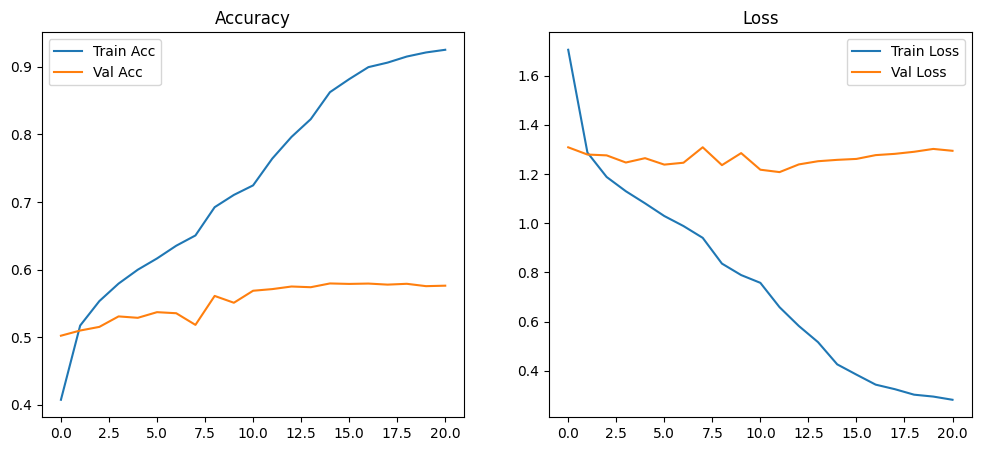

In [9]:
# =========================
# PLOT ACC & LOSS
# =========================
def plot_history(h1, h2, out_dir):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.savefig(os.path.join(out_dir,'accuracy_loss_curve.png'))
    plt.show()

plot_history(history_fe, history_ft, OUT_DIR)

In [10]:
# TEST EVALUATION
# =========================
model.load_weights(os.path.join(OUT_DIR, 'best_model.h5'))
test_steps = test_generator.samples//BATCH_SIZE + 1
test_loss, test_acc = model.evaluate(test_generator, steps=test_steps)
print(f"Test Accuracy: {test_acc:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 44s 196ms/step - accuracy: 0.5459 - loss: 1.3442
Test Accuracy: 0.5770


225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 171ms/step
              precision    recall  f1-score   support

       angry       0.50      0.49      0.50       958
   disgusted       0.58      0.50      0.53       111
     fearful       0.47      0.39      0.43      1024
       happy       0.79      0.75      0.77      1774
     neutral       0.49      0.64      0.55      1233
         sad       0.44      0.46      0.45      1247
   surprised       0.76      0.63      0.69       831

    accuracy                           0.58      7178
   macro avg       0.58      0.55      0.56      7178
weighted avg       0.59      0.58      0.58      7178



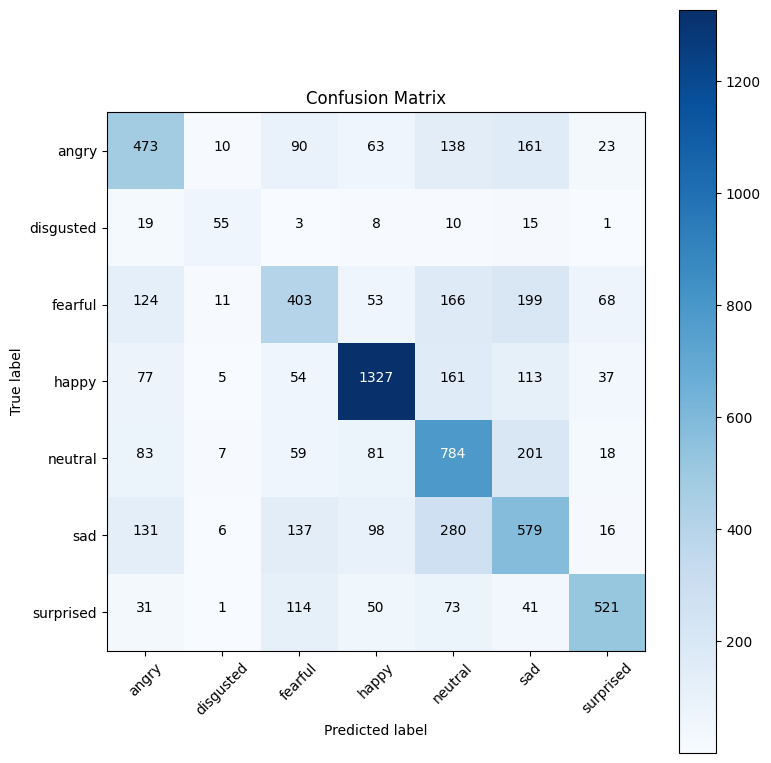

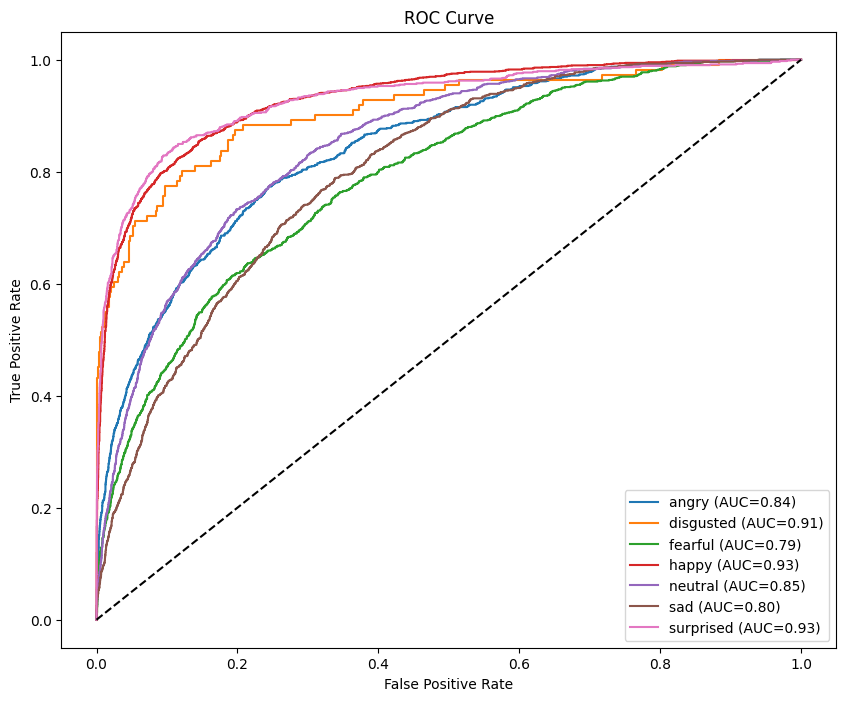

✅ All results saved in: /content/drive/MyDrive/Colab Notebooks/Emotion_VGG16_70_30_Improved_Results_o20251005_141523


In [11]:
# =========================
# CLASSIFICATION REPORT + CONFUSION MATRIX + ROC
# =========================
y_pred_prob = model.predict(test_generator, steps=test_steps)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred, target_names=class_labels)
with open(os.path.join(OUT_DIR,'classification_report.txt'),'w') as f:
    f.write(report)
print(report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)
thresh = cm.max()/2.
for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j,i,cm[i,j], horizontalalignment="center",
             color="white" if cm[i,j] > thresh else "black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'confusion_matrix.png'))
plt.show()

# ROC Curve
plt.figure(figsize=(10,8))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve((y_true==i).astype(int), y_pred_prob[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,tpr,label=f"{class_labels[i]} (AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.savefig(os.path.join(OUT_DIR,'roc_curve.png'))
plt.show()

print("✅ All results saved in:", OUT_DIR)